# Assignment 1: Weather

The file `weather.csv`, available on Canvas, originally from [the CORGIS dataset project](https://corgis-edu.github.io/corgis/csv/weather/), contains weather reports from various weather stations across the United States. In this assignment, we practise the use of some basic data science Python libraries using the data in question.

## General instructions
- Do not rename the dataset file `weather.csv`; the file is available on the autograder precisely under that name.
- Do not remove the `# Codegrade Tag comments`; they are used by the autograder to locate important code cells. Removing them will cause the grading to fail.
- Do not include your name, person number, or any other such personally identifiable material in your answers. For the purpose of grading, your submissions by their metadata.
- Do not use generative AI to generate answers. While generative AI can be a great tool to improve productivity, one must become proficient first oneself in order to make good use of it.
- Do not copy snippets of code from the Internet without attributing them (add an appropriate reference).
- Do **not** copy other students' code. You may discuss your solutions with your classmates but you are not allowed to copy their code.
- Related to above, do **not** publish your code. Do not submit your solutions to a public GitHub repository, for example.
- If you fail to comply with the rules regarding plagiarism above, you will be reported to the unversity disciplinary board and may be suspended.

## Research consent
We would like to use your answers for research purposes. We are conducting a master thesis where automatic grading of plots is investigated. During this course, the plots will be graded manually. However, we would like to use as many submissions as possible for evaluating the AI-based automatic grader that is being developed as part of the master thesis.

Your submissions will be exported in bulk from CodeGrade and the **Python code** is extracted from the notebooks. All textual answers are removed and the code snippets are anonymized in such a way that it will not be possible to link them back to individual students. The data will not be made public and will only be accessed by the master thesis workers and their supervisor (the examiner of this course).

Please set the variable `RESEARCH_CONSENT` to be either `True` or `False`, depending if you agree to participate in the research or not, respectively. That is, if you set the variable `True`, your data will be used for research. If you set the variable `False`, your submission will be removed from the dataset.

The autograder will not give you a grade unless you set the variable either `True` or `False`.

In [ ]:
# Codegrade Tag ResearchConsent
# Do *not* remove the tag above
# Redefine the variable below to False if you do not want to participate in research
RESEARCH_CONSENT = True

## Question 1: Importing tools

For this assignment, we are going to need the following libraries: NumPy, Matplotlib, and Pandas.

Import all three libraries using their standard aliases. Write your answer in the following cell. Do not remove the magical CodeGrade tag comment.

In [2]:
# Codegrade Tag Question1
# Do *not* remove the tag above

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Question 2: Reading data

Use Pandas to read the dataset `weather.csv` into a Pandas dataframe called `df`.

In [90]:
# Codegrade Tag Question2
# Do *not* remove the tag above

df = pd.read_csv("weather.csv")

## Question 3: Unit conversion

The column `Data.Temperature.Avg Temp` contains the daily average temperature at the station in Fahrenheit. Add a new column to `df` called `Average Temperature Celsius` that contains the daily average temperature in celsius. Likewise, the column `Data.Precipitation` contains the amount of rainfall in inches. Add a column to `df` called `Precipitation mm` that contains the precipitation in millimetres.

**Note.** You are supposed to do this using array operations. You must not use a `for` or a `while` loop.

**Hint.** If you can't remember how to convert between °F and °C, see [the Wikipedia article](https://en.wikipedia.org/wiki/Fahrenheit#Conversion_(specific_temperature_point)). If you can't remember how to convert between inches and millimetres, see [the Wikipedia article](https://en.wikipedia.org/wiki/Inch).

In [94]:
# Codegrade Tag Question3
# Do *not* remove the tag above
df["Average Temperature Celsius"] = (df["Data.Temperature.Avg Temp"] - 32) * 5 / 9

df["Precipitation mm"] = df["Data.Precipitation"] * 25.4

## Question 4
Create a new dataframe called `df_sf` that contains only observations from San Francisco. Then, create a line plot of the daily average temperature (in °C) as a function of the date using matplotlib.

That is, you should produce a plot that
- has date on the $x$-axis,
- the temperature on the $y$-axis,
- has a descriptive title (the title should mention that the mesurements are from San Francisco, so the title is assumed to contain the string `San Francisco`),
- has labelled axes (including the unit on the $y$-axis); the $x$-axis label is assumed to contain the string `Date` and the $y$-axis label the strings `Temperature` and `°C`.

**Hints.**
By default, the content of the date column is treated as strings. This will create very awkward ticks on the $x$-axis. This can be fixed by converting the dates into actual date objects using `pd.to_datetime`.

Text(0.5, 1.0, 'Average Temperature by date in San Francisco')

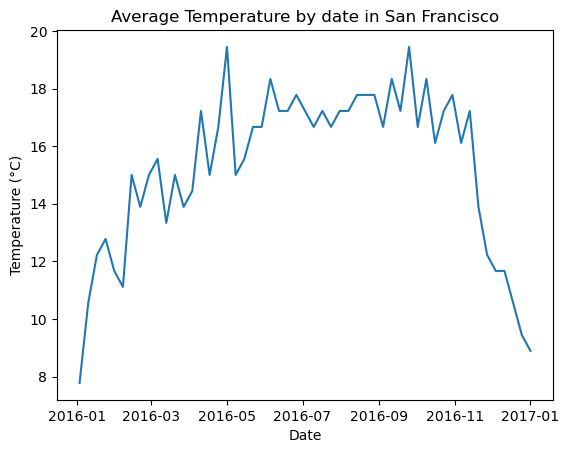

In [85]:
# Codegrade Tag Question4
# Do *not* remove the tag above

df_sf = df[df["Station.City"] == "San Francisco"]
plt.plot(pd.to_datetime(df_sf["Date.Full"]), df_sf["Average Temperature Celsius"])
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Average Temperature by date in San Francisco")

## Question 5

The data we have has been provided for us in long format, that is, we have one one row per observation, and each row contains several variables (this could be in an even longer format if we had a column that would indicate the variable in question and then another contain would contain the value of said variable).

Let us create two dataframes that contain a wide format for one variable in different cities. We will construct the following data frames:
- `df_aktxma` contains only observations from *Anchorage, AK*, *Boston, MA*, and *Dallas-Fort Worth, TX*. The format is otherwise exactly the same as in `df` and we use this to construct the next two dataframes.
- `df_aktxma_temperature` contains exactly three columns: one corresponding to Anchorage, AK, one to Boston, MA, and one to Dallas-Fort Worth, TX. The columns record the daily average temperature. The index of the dataframe is the date. The index must be in `datetime64[ns]` format (**not** as strings). The columns must be flat (single-level), not hierarchical.
- `df_aktxma_precipitation` is just like above, but contains the precipitation in millimetres instead.

**Hints.**
- `pivot` is a useful method for *pivoting* the data as we want to do here.
- A hierarchical column index can be flattened with the method `get_level_values`.
- The index can be converted into the correct data type with `pd.to_datetime`.

In [97]:
# Codegrade Tag Question5
# Do *not* remove the tag above
locations = ['Anchorage, AK', 'Boston, MA', 'Dallas-Fort Worth, TX']
df_aktxma = df[df['Station.Location'].isin(locations)]
 
df_aktxma_temperature = df_aktxma.pivot_table(index='Date.Full',
                                               columns='Station.Location',
                                               values='Average Temperature Celsius',
                                               aggfunc='mean')

df_aktxma_temperature.columns = df_aktxma_temperature.columns.get_level_values(0)
df_aktxma_temperature.index = pd.to_datetime(df_aktxma_temperature.index)
 
df_aktxma_precipitation = df_aktxma.pivot_table(index='Date.Full',
                                                columns='Station.Location',
                                                values='Precipitation mm',
                                                aggfunc='mean')

df_aktxma_precipitation.columns = df_aktxma_precipitation.columns.get_level_values(0)
df_aktxma_precipitation.index = pd.to_datetime(df_aktxma_precipitation.index)

## Question 6
Plot the content of `df_aktxma_temperature`. That is, plot three lines that show the daily average temperature in the three different cities.

Technical requirements:
- There must be three distinct lines in the same plot,
- There must be a **legend** that tells which line corresponds to which city,
- The date is on the $x$-axis and the label includes the string `Date`,
- The temperature is on the $y$-axis and the label includes the strings `Temperature` and `°C`,
- There is a descriptive title.

**Caveat.**
Although it is possible to add a legend with `plt.legend(['text'])`, you should instead add a **label** when plotting lines. This is because it is very difficult to extract free-standing legends, and it is also good practice to label your lines (then there's a clear correspondence between the drawings and the label information). So, in short, don't do
```
plt.plot(x,y)
plt.legend(['a nice curve'])
```
instead, do
```
plt.plot(x,y,label='a nice curve')
plt.legend()
```
This holds for other questions where a legend is requested as well.

Text(0.5, 1.0, 'Daily average temperature by location')

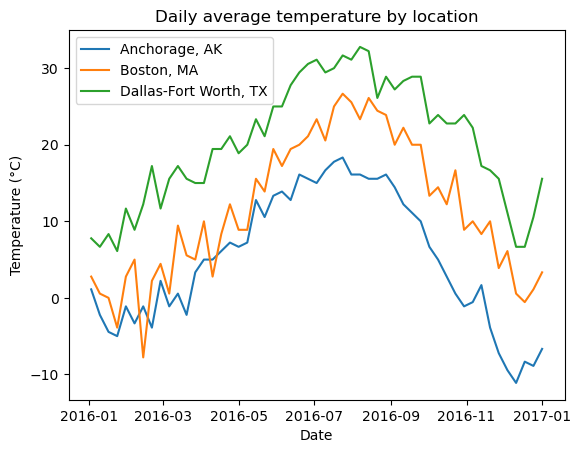

In [79]:
# Codegrade Tag Question6
# Do *not* remove the tag above

for location in df_aktxma_temperature.columns:
    plt.plot(df_aktxma_temperature.index, df_aktxma_temperature[location], label=location)

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.title('Daily average temperature by location')

## Question 7
Do the same but with the content of `df_aktxma_precipitation`. That is, plot three lines that show the daily precipitation in the three different cities.

Technical requirements:
- There must be three distinct lines in the same plot,
- There must be a **legend** that tells which line corresponds to which city,
- The date is on the $x$-axis and the label includes the string `Date`,
- The precipitation is on the $y$-axis and the label includes the strings `Precipitation` and `mm`,
- There is a descriptive title.

Text(0.5, 1.0, 'Daily average precipitation by location')

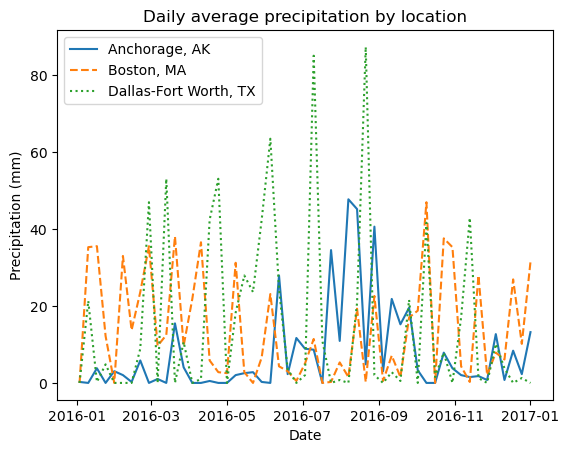

In [84]:
# Codegrade Tag Question7
# Do *not* remove the tag above
linstyles = ['-', '--', ':']
for location, linstyle in zip(df_aktxma_precipitation.columns,linstyles):
    plt.plot(df_aktxma_precipitation.index, df_aktxma_precipitation[location], label=location,linestyle=linstyle)

plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.title('Daily average precipitation by location')

## Question 8

Discuss the two plots above. What does this tell about the climate of the cities? How similar are they, and how do they differ? Why? Find out and dicuss *shortly*.

(You are expected to write 3-4 paragraphs, not more; the discussion should be meaningful, but remember that this is not a class in meteorology.)

*Write your answer in this cell*

In [ ]:
The above two plots of daily temperature and perception for the three cities show a clear picture of the climatic conditions. 
The temperature graph shows how the daily average temperature varies in all three cities, which shows how warm and cold each city is.
Both the plots seem to follow each other.

Dallas has higher daily average temperatures than the other two cities each day. Of these three cities, Anchorage has lower temperatures 
than the others. Dallas never drops below minus degrees. Boston has cooler temperatures than Anchorage on some days in the spring, 
but overall it has higher temperatures. In December 2016, the average temperature in Anchorage dropped to -10 degrees, but in Dallas, 
the temperature never dropped to minus degrees between 2016 and 2017, while in Boston it only dropped to minus degrees in February 2016. 
Other than this time, both Boston and Dallas did not drop below minus degrees. This shows that between 2016 and 2017, the average temperature 
was highest in Dallas, followed by Boston and Anchorage with the lowest temperatures. Therefore, Boston and Dallas are closer to each other 
in terms of temperature patterns, while Anchorage remains separate from them. All three locations are in the Northern Hemisphere, and 
Anchorage is quite far north of Boston and Dallas. Therefore, due to its geographical location, it is normal for temperatures to be 
lower and this is consistent with the results of the data.

Dallas has the highest precipitation. In the summer months, precipitation in Dallas and Anchorage increases compared to the amount 
of precipitation they receive throughout the year. Boston receives more precipitation throughout the year, but less precipitation between 
July and September. Between 2016 and 2017, Dallas received over 80 mm of precipitation in July and September of 2016, but the amount of 
precipitation dropped to almost 0 in August. Boston and Anchorage are closer to each other in terms of precipitation. Anchorage receives the 
most rainfall between July and September of 2016.

As a summary, Dallas has the highest warm temperature and Anchorage has the coldest temperature. Boston’s weather lies in between the other
two and sometimes seems to be dropping below Dallas’s weather. Looking at the precipitation plot, Dallas seems to have the highest value 
whereas both Anchorage and Boston have almost similar precipitation. During the summer, Anchorage seems to have the most precipitation 
whereas Boston has the lowest. Looking at the plot, Dallas seems to have very unpredictable precipitation.